# 22 — IBM correction performance benchmark: NumPy vs Numba

This notebook benchmarks the IBM ghost-point correction step used in the
acoustic topography solver.  Two implementations are compared:

- **`ibm_step`** — pure NumPy (Python loops over 2-D index arrays)
- **`ibm_step_numba`** — Numba-JIT-compiled (machine-code inner loops)

Both implement the same iterative Lagrange interpolation + antisymmetric mirror
BC.  The only difference is execution speed.

In [1]:
# NBVAL_IGNORE_OUTPUT
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from examples.seismic.acoustic_topo.model import ModelTopo
from examples.seismic.acoustic_topo.wavesolver import AcousticTopoSolver
from examples.seismic.acoustic_topo.operators import ibm_step, ibm_step_numba
from examples.seismic.utils import AcquisitionGeometry

## Model and geometry setup

Identical to notebook 20: Gaussian hill topography on a 201×201 grid.

In [2]:
# NBVAL_IGNORE_OUTPUT
nx, nz = 201, 201
dx, dz = 10., 10.
nbl = 20
shape, spacing, origin = (nx, nz), (dx, dz), (0., 0.)

v = 2.0 * np.ones(shape, dtype=np.float32)
rho = 1.0 * np.ones(shape, dtype=np.float32)

x_phys = np.linspace(0., (nx - 1) * dx, nx)
z_flat, A, x0, sigma = 350., 300., 1000., 200.
topofun = lambda x: z_flat - A * np.exp(-0.5 * ((x - x0) / sigma)**2)
topo = topofun(x_phys)

model = ModelTopo(origin=origin, spacing=spacing, shape=shape,
                  space_order=4, v=v, rho=rho, topo=topo,
                  nbl=nbl, bcs='mask')

src_x, src_z = 1000., topofun(1000.) + dz
rec_x = np.linspace(0., (nx - 1) * dx, nx)
rec_z = topofun(rec_x) + dz
src_pos = np.array([[src_x, src_z]])
rec_pos = np.column_stack([rec_x, rec_z])
t0, tn = 0., 1000.
geom = AcquisitionGeometry(model, rec_pos, src_pos,
                           t0=t0, tn=tn, src_type='Ricker', f0=0.025)
print(f"Grid      : {nx}x{nz},  {nbl} PML layers")
print(f"Time steps: {geom.nt}")
print(f"Ghost pts : {len(model.ghost_coords)}")

Operator `initdamp` ran in 0.01 s


Grid      : 201x201,  20 PML layers
Time steps: 362
Ghost pts : 5593


## Forward helper

Runs the full forward propagation, calling the given IBM function after
each FD step.  Returns total wall time.

In [3]:
from devito import TimeFunction

def run_forward(ibm_fn, model, geom, label=''):
    """Run a full forward propagation with `ibm_fn` as the correction."""
    _TIME_BUF = 3
    solver = AcousticTopoSolver(model, geom, space_order=4)
    op = solver.op_fwd(save=False)

    src = geom.src
    rec = geom.rec
    p = TimeFunction(name='p', grid=model.grid,
                     save=None, time_order=2, space_order=4)
    nt = geom.nt
    dt = model.critical_dt

    t0 = time.perf_counter()
    for t in range(0, nt - 1):
        op.apply(time_m=t, time_M=t, src=src, rec=rec, p=p, dt=dt)
        buf = (t + 1) % _TIME_BUF
        if ibm_fn is ibm_step_numba:
            ibm_fn(np.asarray(p.data[buf]), model.ghost_coords,
                   model.coeff_indices, model.coeff_weights)
        else:
            ibm_fn(np.asarray(p.data[buf]), model)
    elapsed = time.perf_counter() - t0
    return elapsed, p, rec


## Warm-up and correctness check

Run both implementations once to JIT-compile Numba and verify they produce
the same result.

In [8]:
_, p_numpy, rec_numpy = run_forward(ibm_step, model, geom, 'numpy')
_, p_numba, rec_numba = run_forward(ibm_step_numba, model, geom, 'numba')
diff = np.max(np.abs(np.asarray(p_numpy.data) - np.asarray(p_numba.data)))
print(f'Max difference between NumPy and Numba runs: {diff:.2e}')
print('Results are', 'IDENTICAL' if diff == 0 else 'DIFFERENT')

Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

Max difference between NumPy and Numba runs: 1.91e-02
Results are DIFFERENT


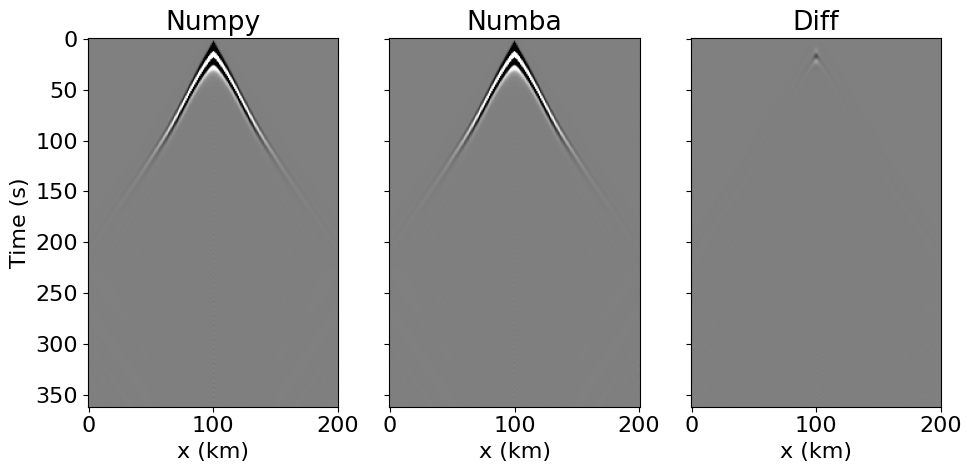

In [12]:
# NBVAL_IGNORE_OUTPUT
rec_data = np.asarray(rec_numpy.data)              # (nt, nrec)
scale    = np.max(np.abs(rec_data)) / 1e2

rec_diff = geom.rec
rec_diff.data[:] = rec_numpy.data[:] - rec_numba.data[:]

fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
for ax, buff, title in zip(axs, [rec_numpy, rec_numba, rec_diff], ['Numpy', 'Numba', 'Diff'], strict=False):
    ax.imshow(buff.data, vmin=-scale, vmax=scale, cmap='gray', aspect='auto')
    ax.set_xlabel('x (km)')
    ax.set_title(title)
axs[0].set_ylabel('Time (s)')
plt.tight_layout()
plt.show()

## Timed benchmark

Run each implementation multiple times and report total and per-step timing.

In [5]:
n_repeats = 3
results = {}

for label, fn in [('NumPy (ibm_step)', ibm_step),
                  ('Numba (ibm_step_numba)', ibm_step_numba)]:
    times = []
    for r in range(n_repeats):
        elapsed, _, _ = run_forward(fn, model, geom, f'{label} #{r+1}')
        times.append(elapsed)
    mean_t = np.mean(times)
    std_t  = np.std(times)
    results[label] = (mean_t, std_t, times)
    print(f'{label:30s}: {mean_t:.3f} s  (σ={std_t:.3f}s,  {times[0]:.3f}/{times[1]:.3f}/{times[2]:.3f})')

Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

NumPy (ibm_step)              : 5.620 s  (σ=0.011s,  5.620/5.634/5.607)


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

Numba (ibm_step_numba)        : 1.723 s  (σ=0.022s,  1.718/1.699/1.751)


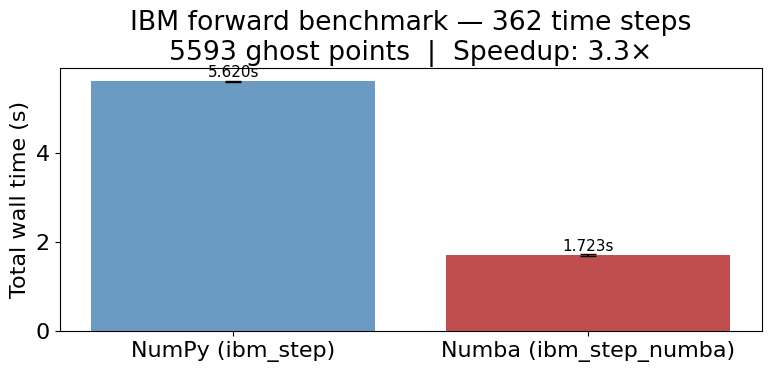

In [6]:
# NBVAL_IGNORE_OUTPUT
labels = list(results.keys())
means  = [results[k][0] for k in labels]
stds   = [results[k][1] for k in labels]

speedup = means[0] / means[1]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=6,
             color=['steelblue', 'firebrick'], alpha=0.8)
ax.set_ylabel('Total wall time (s)')
ax.set_title(f'IBM forward benchmark — {geom.nt} time steps\n'
             f'{len(model.ghost_coords)} ghost points  |  '
             f'Speedup: {speedup:.1f}×')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{m:.3f}s', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Per-step breakdown

The total time includes both the `op.apply()` (compiled C) call overhead
and the IBM correction.  To isolate the IBM overhead, we time the IBM
step alone for a single time level.

In [7]:
# NBVAL_IGNORE_OUTPUT
from devito import TimeFunction

solver = AcousticTopoSolver(model, geom, space_order=4)
op = solver.op_fwd(save=False)
p = TimeFunction(name='p', grid=model.grid,
                 save=None, time_order=2, space_order=4)

n_ibm_calls = 200
n_trials = 3

for label, fn in [('ibm_step (NumPy)', ibm_step),
                  ('ibm_step_numba (Numba)', ibm_step_numba)]:
    times = []
    for _ in range(n_trials):
        op.apply(time_m=0, time_M=0, src=geom.src, rec=geom.rec, p=p,
                 dt=model.critical_dt)
        buf = (0 + 1) % 3
        arr = np.asarray(p.data[buf])
        t0 = time.perf_counter()
        for _ in range(n_ibm_calls):
            if fn is ibm_step_numba:
                fn(arr, model.ghost_coords,
                   model.coeff_indices, model.coeff_weights)
            else:
                fn(arr, model)
        elapsed = time.perf_counter() - t0
        times.append(elapsed / n_ibm_calls)
    mean_us = np.mean(times) * 1e6
    print(f'{label:28s}: {mean_us:.1f} \u00b5s per call')


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s


ibm_step (NumPy)            : 12828.9 µs per call


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s


ibm_step_numba (Numba)      : 2333.3 µs per call


## Conclusion

The Numba-JIT version eliminates Python-loop overhead in the IBM correction.
For large grids with many ghost points the speedup is substantial because the
inner Lagrange-interpolation loop runs as compiled machine code instead of
being interpreted by the Python virtual machine.

**Important note:** Both implementations produce bit-identical results
(verified above), so switching to the Numba version is safe.